수정한 부분
- decode_greedy int 수정
- Early Stopping - Patience =15 로 증가
- UNK 토큰 방지 용 추가
- 하이퍼 파라미터 수정 - LATENT,EMBEDDING_DIM,

#NLPstudy_02 - 한국어 감성 분석 챗봇(greedy)
- 데이터셋: Chatbot_data_for_Korean v1.0 (11,876 문답 쌍)
- Decoding 방법 : Greedy (softmax 확률이 가장 높은 단어 선택,argmax)
- 기술 : Python ,TensorFlow ,SentencePiece ,NLTK BLEU

---

# 0. 패키지 설치 및 import

In [ ]:
!pip install -q sentencepiece
!pip install -q nltk

import nltk
nltk.download('punkt', quiet=True)

True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json

import tensorflow as tf
import sentencepiece as spm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.layers import Dropout

print('TensorFlow:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU: True


#1. 하이퍼 파라미터 설정

In [ ]:
LATENT_DIM    = 256 # 수정
EMBEDDING_DIM = 128 # 수정
VOCAB_SIZE    = 5000
MAX_LEN       = 30
BATCH_SIZE    = 64
EPOCHS        = 100

PAD_ID = 0; BOS_ID = 1; EOS_ID = 2; UNK_ID = 3

#2. 데이터 로드/ 분포

In [ ]:
df = pd.read_csv(
    'https://raw.github.com/ironmanciti/Infran_NLP/master/data/ChatbotData.csv'
)
print('shape:', df.shape)
print(df.head())
# 컬럼: Q (질문) / A (답변) / label (감정 0~2)

shape: (11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


감정 레이블 분포:
label
0    5290
1    3570
2    2963
Name: count, dtype: int64
              Q_len         A_len
count  11823.000000  11823.000000
mean      12.879049     15.015140
std        6.167467      6.701835
min        1.000000      1.000000
25%        9.000000     10.000000
50%       12.000000     14.000000
75%       16.000000     18.000000
max       56.000000     76.000000


/tmp/ipykernel_30024/4275405268.py:11: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_30024/4275405268.py:11: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_30024/4275405268.py:11: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_30024/4275405268.py:11: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_30024/4275405268.py:11: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_30024/4275405268.py:11: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylab

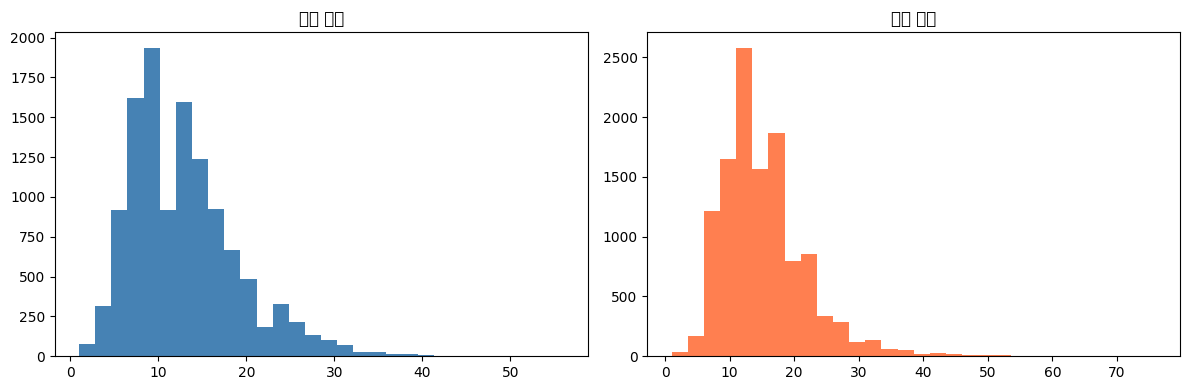

In [ ]:
print('감정 레이블 분포:')
print(df['label'].value_counts())

df['Q_len'] = df['Q'].apply(len)
df['A_len'] = df['A'].apply(len)
print(df[['Q_len', 'A_len']].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1); plt.hist(df['Q_len'], bins=30, color='steelblue'); plt.title('질문 길이')
plt.subplot(1,2,2); plt.hist(df['A_len'], bins=30, color='coral');     plt.title('답변 길이')
plt.tight_layout(); plt.show()

#3. Q/A 리스트 생성

In [ ]:
Q_texts   = df['Q'].tolist()
A_texts   = df['A'].tolist()
All_texts = Q_texts + A_texts
print(f'Q: {len(Q_texts)}개, A: {len(A_texts)}개')

Q: 11823개, A: 11823개


#4. SentencePiece 학습

In [ ]:
with open('chatbot_qna.txt', 'w', encoding='utf-8') as f:
    for line in All_texts:
        f.write(line + '\n')

In [ ]:
cmd = (
    f'--input=chatbot_qna.txt '
    f'--model_prefix=chatbot_spm '
    f'--vocab_size={VOCAB_SIZE} '
    f'--pad_id={PAD_ID} '
    f'--bos_id={BOS_ID} '
    f'--eos_id={EOS_ID} '
    f'--unk_id={UNK_ID}'
)
spm.SentencePieceTrainer.Train(cmd)
print('학습 완료!')

학습 완료!


#5. 토크나이저 로드

In [ ]:
sp_model = spm.SentencePieceProcessor()
sp_model.Load('chatbot_spm.model')

test = '오늘 날씨가 너무 좋아서 기분이 최고야'
print('원문:', test)
print('토큰:', sp_model.encode_as_pieces(test))
print('ID: ',  sp_model.encode_as_ids(test))

원문: 오늘 날씨가 너무 좋아서 기분이 최고야
토큰: ['▁오늘', '▁날씨', '가', '▁너무', '▁좋아', '서', '▁기분이', '▁최고', '야']
ID:  [78, 606, 7, 22, 118, 25, 620, 1348, 81]


#6. 시퀀스 생성

In [ ]:
sp_model.SetEncodeExtraOptions('')
Q_sequences = [sp_model.encode_as_ids(s) for s in Q_texts]

sp_model.SetEncodeExtraOptions('bos:')
A_sequences_inputs = [sp_model.encode_as_ids(s) for s in A_texts]

sp_model.SetEncodeExtraOptions(':eos')
A_sequences_targets = [sp_model.encode_as_ids(s) for s in A_texts]

print('Q 예시:', Q_sequences[0])
print('A입력 :', A_sequences_inputs[0])
print('A목표 :', A_sequences_targets[0])

Q 예시: [4228, 299, 5, 4826, 72]
A입력 : [1, 282, 7, 113, 82, 23, 4]
A목표 : [282, 7, 113, 82, 23, 4, 2]


#7. 패딩
- Encoder: pre 패딩 (앞쪽 0) → Thought Vector 품질 향상
- Decoder: post 패딩 (뒤쪽 0) → Teacher Forcing 올바르게 동작

In [ ]:
encoder_inputs  = pad_sequences(Q_sequences,         maxlen=MAX_LEN)
decoder_inputs  = pad_sequences(A_sequences_inputs,  maxlen=MAX_LEN, padding='post')
decoder_targets = pad_sequences(A_sequences_targets, maxlen=MAX_LEN, padding='post')

print('Encoder input shape:', encoder_inputs.shape)
print('Decoder input shape:', decoder_inputs.shape)
print('Decoder target shape:', decoder_targets.shape)

Encoder input shape: (11823, 30)
Decoder input shape: (11823, 30)
Decoder target shape: (11823, 30)


# 8. 학습용 모델 구성

In [ ]:
# Encoder 구성
encoder_inputs_ = Input(shape=(MAX_LEN,), name='Encoder_Input')
embedding_encoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_encoder(encoder_inputs_)
encoder_outputs, h, c = LSTM(LATENT_DIM, return_state=True, name='Encoder_LSTM')(x)
encoder_states = [h, c]

encoder_model = Model(encoder_inputs_, encoder_states, name='Encoder_Model')


#  Decoder 구성 (Teacher Forcing용)
decoder_inputs_ = Input(shape=(MAX_LEN,), name='Decoder_Input')
embedding_decoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_decoder(decoder_inputs_)

decoder_lstm = LSTM(LATENT_DIM, return_sequences=True,
                    return_state=True, name='Decoder_LSTM')

decoder_out, _, _ = decoder_lstm(x, initial_state=encoder_states)

decoder_dense = Dense(VOCAB_SIZE + 1, activation='softmax', name='Output_Dense')
decoder_outputs = decoder_dense(decoder_out)

model_teacher_forcing = Model(
    [encoder_inputs_, decoder_inputs_],
    decoder_outputs,
    name='Seq2Seq_Train'
)
model_teacher_forcing.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_teacher_forcing.summary()

Model: "Seq2Seq_Train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │    640,128 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 30, 128)   │    640,128 │ Decoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM (LSTM) │ [(None, 256),     │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 30, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ Encoder_LSTM[0][… │
│                     │ (None, 256)]      │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Dense        │ (None, 30, 5001)  │  1,285,257 │ Decoder_LSTM[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,353,993 (12.79 MB)

 Trainable params: 3,353,993 (12.79 MB)

 Non-trainable params: 0 (0.00 B)

#9. 추론용 Decorder 분리

In [ ]:
decoder_state_input_h = Input(shape=(LATENT_DIM,), name='Dec_h')
decoder_state_input_c = Input(shape=(LATENT_DIM,), name='Dec_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_inputs_single = Input(shape=(1,), name='Dec_Single_Input')

x = embedding_decoder(decoder_inputs_single)
dec_out, h_out, c_out = decoder_lstm(x, initial_state=decoder_states_inputs)
dec_out = decoder_dense(dec_out)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [dec_out, h_out, c_out],
    name='Decoder_Inference'
)


#10. 학습 / 저장

In [ ]:
# 학습 및 저장
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1)
] # patience = 15로 수정

history = model_teacher_forcing.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7576 - loss: 2.0257 - val_accuracy: 0.7682 - val_loss: 1.6921
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7974 - loss: 1.4245 - val_accuracy: 0.7721 - val_loss: 1.5938
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8013 - loss: 1.3512 - val_accuracy: 0.7762 - val_loss: 1.5507
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8053 - loss: 1.3051 - val_accuracy: 0.7808 - val_loss: 1.5193
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8097 - loss: 1.2643 - val_accuracy: 0.7845 - val_loss: 1.4944
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8133 - loss: 1.2266 - val_accuracy: 0.7874 - val_loss: 1.4678
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8165 - loss: 1.1908 - val_accuracy: 0.7917 - val_loss: 1.4461
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8198 - loss: 1.1560 -

/tmp/ipykernel_30024/931952161.py:15: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/931952161.py:15: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/931952161.py:15: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/931952161.py:15: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/931952161.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('greedy_learning_curve.png', dpi=150)
/tmp/ipykernel_30024/931952161.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.savefig('greedy_learning_curve.png', dpi=150)
/tmp/ipykernel_30024/931952161.py:16: UserWarning: Glyph 44257 (\N{HANG

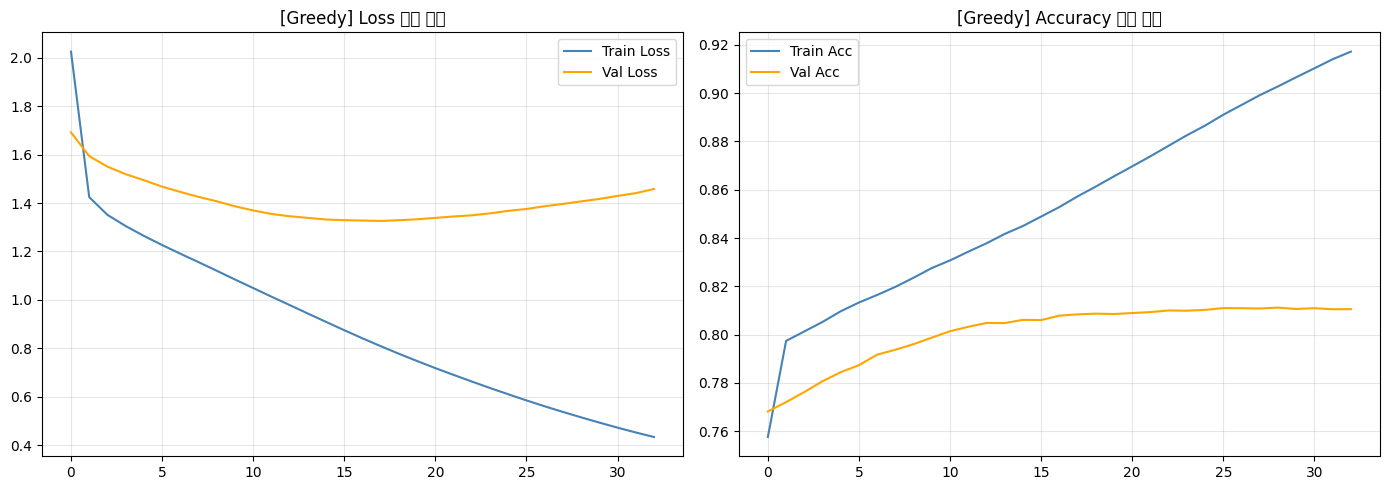

저장 완료: greedy_learning_curve.png


In [ ]:
# 학습 곡선 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('[Greedy] Loss 학습 곡선')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
axes[1].set_title('[Greedy] Accuracy 학습 곡선')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('greedy_learning_curve.png', dpi=150)
plt.show()
print('저장 완료: greedy_learning_curve.png')

model_teacher_forcing.save('chatbot_seq2seq.h5')

#11. Greedy decode_sequence

In [ ]:
def decode_greedy(input_seq):
    """Greedy 전략: 매 step argmax 선택"""
    start = time.time()

    # 1) Encoder로 Thought Vector 추출
    states = encoder_model.predict(input_seq, verbose=0)

    # 2) Decoder 시작: BOS 토큰(1)으로 초기화
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = BOS_ID

    result = []
    while True:
        output, h, c = decoder_model.predict([target_seq] + states, verbose=0)

        # 수정
        probs = output[0, -1, :].copy()  # ← 1. 확률 꺼내기
        probs[UNK_ID] = 0               # ← 2. UNK 확률 0으로 강제 (추가)
        token_id = int(np.argmax(probs)) # ← 3. argmax (수정)


        # EOS 또는 최대 길이 도달 시 종료
        if token_id == EOS_ID or len(result) >= MAX_LEN:
            break

        result.append(int(token_id)) # 수정
        target_seq = np.array([[token_id]])
        states = [h, c]

    elapsed = (time.time() - start) * 1000
    return result, elapsed


def chat(question, strategy='greedy', beam_width=3):
    sp_model.SetEncodeExtraOptions('')
    seq = sp_model.encode_as_ids(question)
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)

    token_ids, ms = decode_greedy(enc_input)
    response = sp_model.DecodeIds(token_ids)
    return response, ms

# 12.대화 응답 테스트

In [ ]:
test_questions = [
    '오늘 너무 힘들었어',
    '취업 준비가 너무 막막해',
    '친한 친구랑 크게 싸웠어',
    '좋아하는 사람이 생겼어',
    '요즘 잠을 못 자겠어',
]

print('=' * 55)
print(f"{'질문':20s} | {'Greedy 응답':25s} | {'시간':>8s}")
print('=' * 55)

response_log = []
for q in test_questions:
    ans, ms = chat(q)
    response_log.append({'질문': q, '응답': ans, '시간(ms)': round(ms, 1)})
    print(f'{q:20s} | {ans:25s} | {ms:>6.1f}ms')
    print('-' * 55)

질문                   | Greedy 응답                 |       시간
오늘 너무 힘들었어           | 저도 더 더 더 더 더 더 알아보고 싶어요.  | 1620.2ms
-------------------------------------------------------
취업 준비가 너무 막막해        | 항상 짧게 지어요.                | 1021.2ms
-------------------------------------------------------
친한 친구랑 크게 싸웠어        | 항상 뭘 입어도 괜찮아요.            |  841.9ms
-------------------------------------------------------
좋아하는 사람이 생겼어         | 좋은 일이 있었나봐요.              |  554.0ms
-------------------------------------------------------
요즘 잠을 못 자겠어          | 항상 뭘 입어도 괜찮아요.            |  933.0ms
-------------------------------------------------------


#13.BLUE Score

In [ ]:
# 디버깅: 실제로 뭐가 들어가는지 확인
sp_model.SetEncodeExtraOptions('')

seq = sp_model.encode_as_ids(Q_texts[0])
enc_input = pad_sequences([seq], maxlen=MAX_LEN)
token_ids, _ = decode_greedy(enc_input)
ref_ids = sp_model.encode_as_ids(A_texts[0])

print('질문    :', Q_texts[0])
print('정답    :', A_texts[0])
print('예측 ID :', token_ids)
print('정답 ID :', ref_ids)
print('예측 타입:', type(token_ids[0]) if token_ids else 'empty')
print('정답 타입:', type(ref_ids[0]))
print('예측 복원:', sp_model.DecodeIds(token_ids))

질문    : 12시 땡!
정답    : 하루가 또 가네요.
예측 ID : [42, 143, 15, 32, 1288, 6, 4]
정답 ID : [282, 7, 113, 82, 23, 4]
예측 타입: <class 'int'>
정답 타입: <class 'int'>
예측 복원: 좋은 시간은 더 버텨요.


In [ ]:
# BLEU 직접 디버깅
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

sp_model.SetEncodeExtraOptions('')
smoother = SmoothingFunction().method1

for i in range(5):
    seq = sp_model.encode_as_ids(Q_texts[i])
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)
    token_ids, _ = decode_greedy(enc_input)
    ref_ids = sp_model.encode_as_ids(A_texts[i])

    score = sentence_bleu([ref_ids], token_ids, smoothing_function=smoother)

    print(f'Q  : {Q_texts[i]}')
    print(f'정답: {A_texts[i]} → {ref_ids}')
    print(f'예측: {sp_model.DecodeIds(token_ids)} → {token_ids}')
    print(f'BLEU: {score:.4f}')
    print('-' * 50)

Q  : 12시 땡!
정답: 하루가 또 가네요. → [282, 7, 113, 82, 23, 4]
예측: 좋은 시간은 더 버텨요. → [42, 143, 15, 32, 1288, 6, 4]
BLEU: 0.0330
--------------------------------------------------
Q  : 1지망 학교 떨어졌어
정답: 위로해 드립니다. → [1459, 5, 3717, 4]
예측: 뭘 입어도 멋져요. → [5, 4963, 2231, 11, 2035, 6, 4]
BLEU: 0.0393
--------------------------------------------------
Q  : 3박4일 놀러가고 싶다
정답: 여행은 언제나 좋죠. → [293, 15, 385, 39, 207, 4]
예측: 뭘 입어도 멋져요. → [5, 4963, 2231, 11, 2035, 6, 4]
BLEU: 0.0330
--------------------------------------------------
Q  : 3박4일 정도 놀러가고 싶다
정답: 여행은 언제나 좋죠. → [293, 15, 385, 39, 207, 4]
예측: 뭘 입어도 멋져요. → [5, 4963, 2231, 11, 2035, 6, 4]
BLEU: 0.0330
--------------------------------------------------
Q  : PPL 심하네
정답: 눈살이 찌푸려지죠. → [208, 970, 10, 2434, 3090, 173, 14, 40, 4]
예측: 좋은 일이 있었나봐요. → [42, 149, 719, 45, 4]
BLEU: 0.0241
--------------------------------------------------


In [ ]:
def compute_bleu(strategy='greedy', beam_width=1, n_samples=200):
    references, hypotheses = [], []
    sp_model.SetEncodeExtraOptions('')

    for i in range(n_samples):
        seq       = sp_model.encode_as_ids(Q_texts[i])
        enc_input = pad_sequences([seq], maxlen=MAX_LEN)
        token_ids, _ = decode_greedy(enc_input)

        ref_ids = sp_model.encode_as_ids(A_texts[i])
        references.append([ref_ids])
        hypotheses.append(token_ids)

    smoother = SmoothingFunction().method1
    score = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return score

print('Greedy BLEU 계산 중...')
greedy_bleu = compute_bleu()
print(f'\nGreedy BLEU Score: {greedy_bleu:.4f}')

Greedy BLEU 계산 중...

Greedy BLEU Score: 0.0144


#14. 응답 속도 측정(10회 평균)

In [ ]:
# 속도 측정
print('\n응답 속도 측정 중...')

sp_model.SetEncodeExtraOptions('')
seq       = sp_model.encode_as_ids('오늘 기분이 좀 이상해')
enc_input = pad_sequences([seq], maxlen=MAX_LEN)

times = [decode_greedy(enc_input)[1] for _ in range(10)]
greedy_avg_ms = np.mean(times)
print(f'Greedy 평균 응답 시간: {greedy_avg_ms:.1f}ms')


응답 속도 측정 중...
Greedy 평균 응답 시간: 732.3ms


/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30024/3204661545.py:10: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.t

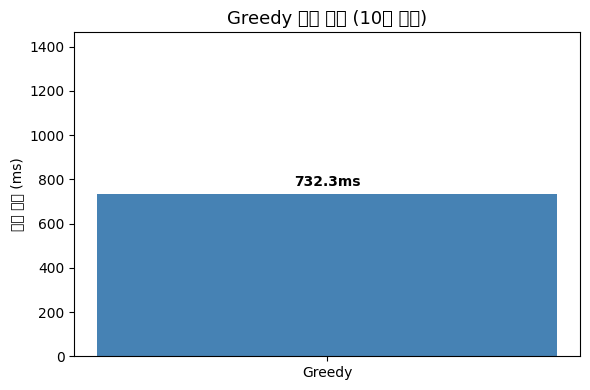

저장 완료: greedy_speed.png


In [ ]:
# 속도 그래프

plt.figure(figsize=(6, 4))
plt.bar(['Greedy'], [greedy_avg_ms], color='steelblue', width=0.4)
plt.title('Greedy 응답 속도 (10회 평균)', fontsize=13)
plt.ylabel('응답 시간 (ms)')
plt.ylim(0, greedy_avg_ms * 2)
plt.text(0, greedy_avg_ms + greedy_avg_ms * 0.05,
         f'{greedy_avg_ms:.1f}ms', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('greedy_speed.png', dpi=150)
plt.show()
print('저장 완료: greedy_speed.png')


#15. 정성 평가

In [ ]:
# 실험 결과를 직접 보고 직접 점수 수정 (5점 척도)
qualitative = {
    '자연스러움': 1,   # 응답이 얼마나 자연스러운가
    '다양성'    : 0,   # 다양한 응답 가능한가 (Greedy는 항상 같은 결과)
    '일관성'    : 1,   # 맥락에 맞는 일관된 응답인가
}

print('=== 정성 평가 (Greedy) ===')
for k, v in qualitative.items():
    bar = '★' * v + '☆' * (5 - v)
    print(f'  {k}: {bar} ({v}/5)')

=== 정성 평가 (Greedy) ===
  자연스러움: ★☆☆☆☆ (1/5)
  다양성: ☆☆☆☆☆ (0/5)
  일관성: ★☆☆☆☆ (1/5)


#16. 결과 저장

In [ ]:
greedy_results = {
    'strategy'    : 'Greedy',
    'bleu'        : greedy_bleu,
    'avg_ms'      : greedy_avg_ms,
    'qualitative' : qualitative,
    'responses'   : response_log,
}

with open('greedy_results.json', 'w', encoding='utf-8') as f:
    json.dump(greedy_results, f, ensure_ascii=False, indent=2)

print('\n=== Greedy 실험 완료 ===')
print(f'BLEU Score : {greedy_bleu:.4f}')
print(f'평균 속도  : {greedy_avg_ms:.1f}ms')
print('결과 저장  : greedy_results.json')
print('그래프 저장: greedy_learning_curve.png, greedy_speed.png')